<a href="https://colab.research.google.com/github/tripti369/AI-voice-detector-/blob/main/Climate_change_modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load your dataset
# Make sure the filename matches exactly what you uploaded to Colab
file_name = 'climate_nasa (1).csv'
data = pd.read_csv(file_name)

# Quick preview of the data [cite: 97, 98]
print("Dataset Preview:")
display(data.head())
print("\nStatistical Summary:")
display(data.describe())

Dataset Preview:


,date,likesCount,profileName,commentsCount,text
0,2022-09-07T17:12:32.000Z,2,4dca617d86b3fdce80ba7e81fb16e048c9cd9798cdfd6d...,NaN,Neat comparison I have not heard it before.\n ...
1,2022-09-08T14:51:13.000Z,0,518ab97f2d115ba5b6f03b2fba2ef2b120540c9681288b...,NaN,An excellent way to visualise the invisible! T...
2,2022-09-07T17:19:41.000Z,1,d82e8e24eb633fd625b0aef9b3cb625cfb044ceb8483e1...,3.0,Does the CO2/ghg in the troposphere affect the...
3,2022-09-08T00:51:30.000Z,4,37a509fa0b5177a2233c7e2d0e2b2d6916695fa9fba3f2...,NaN,excellent post! I defo feel the difference - o...
4,2022-09-07T19:06:20.000Z,16,e54fbbd42a729af9d04d9a5cc1f9bbfe8081a31c219ecb...,26.0,"Yes, and carbon dioxide does not harm the Eart..."



Statistical Summary:


,likesCount,commentsCount
count,522.000000,244.000000
mean,4.720307,8.696721
std,12.053556,12.266176
min,0.000000,1.000000
25%,0.000000,2.000000
50%,1.000000,5.000000
75%,4.000000,10.000000
max,126.000000,93.000000


In [7]:
# Identify your target variable.
# Based on your document, this is likely 'temperature_anomaly' or 'emission' [cite: 101, 324]
target_col = 'likesCount' # Change this to 'emission' if that is your target column

# Separate features and target [cite: 101, 102]
X = data.drop(target_col, axis=1)
y = data[target_col]

# Handle potential non-numeric columns (like IDs or Dates) before training
X = X.select_dtypes(include=[np.number])

# Split into training and testing sets (80/20 split) [cite: 104]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features [cite: 105, 106]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the Random Forest Model [cite: 110]
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions [cite: 112]
y_pred = model.predict(X_test_scaled)

Mean Absolute Error (MAE): 5.5462
Mean Squared Error (MSE): 154.1662
R2 Score: 0.1420


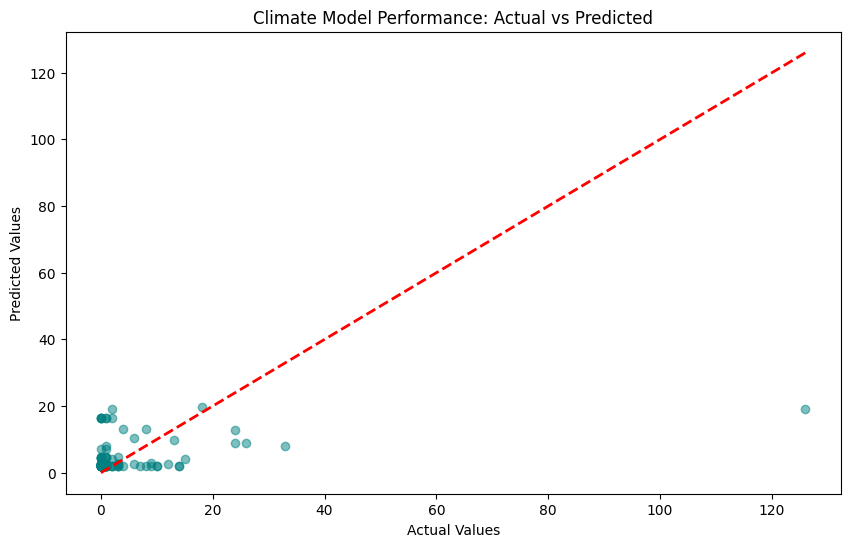

In [8]:
# Calculate evaluation metrics [cite: 117, 118, 119]
print(f'Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.4f}')
print(f'Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.4f}')
print(f'R2 Score: {r2_score(y_test, y_pred):.4f}')

# Plot Actual vs Predicted values [cite: 121, 122, 124]
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Climate Model Performance: Actual vs Predicted')
plt.show()

In [11]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Handle missing values in the 'text' column by filling with an empty string
data['text'] = data['text'].fillna('')

# 1. Vectorize the text: Convert words into a format the AI can understand
# We ignore common 'stop_words' (like 'the', 'is') to focus on meaningful terms [cite: 11]
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
tf = vectorizer.fit_transform(data['text'])

# 2. Train the LDA Model: This looks for 5 hidden topics within the comments [cite: 15]
lda_model = LatentDirichletAllocation(n_components=5, random_state=42)
lda_model.fit(tf)

# 3. Display the Results: Print the top 10 words that define each AI-discovered topic
words = vectorizer.get_feature_names_out()
print("Top 10 words per Topic discovered by LDA:")

for index, topic in enumerate(lda_model.components_):
    print(f"\nTopic #{index + 1}:")
    top_words = [words[i] for i in topic.argsort()[-10:]]
    print(top_words)

Top 10 words per Topic discovered by LDA:

Topic #1:
['sun', 'people', 'just', 'planet', 'warming', 'nasa', 'global', 'earth', 'change', 'climate']

Topic #2:
['global', 'warming', 'human', 'year', 'know', 'weather', 'climate', 'planet', 'start', 'years']

Topic #3:
['nasa', 'science', 'scientists', 'going', 'like', 'getting', 'just', 'change', 'time', 'climate']

Topic #4:
['rise', 'years', 'feet', 'level', 'sea', 'water', 'dioxide', 'atmosphere', 'carbon', 'co2']

Topic #5:
['think', 'energy', 'global', 'temperature', 'man', 'world', 'people', 'change', 'need', 'climate']
